In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:


import pandas as pd


movies = pd.read_csv('movies_metadata.csv', low_memory=False)
credits = pd.read_csv('credits.csv')
links=pd.read_csv('links.csv')


movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
credits['id'] = pd.to_numeric(credits['id'], errors='coerce')




movies.dropna(subset=['id'], inplace=True)
credits.dropna(subset=['id'], inplace=True)


movies['id'] = movies['id'].astype(int)
credits['id'] = credits['id'].astype(int)



links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce')

links.dropna(subset=['tmdbId'], inplace=True)

links['tmdbId'] = links['tmdbId'].astype(int)
data = movies.merge(credits, on='id', how='left')
data = data.merge(links, left_on='id', right_on='tmdbId', how='left')


print(data.shape)
data.head()

(45669, 29)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,movieId,imdbId,tmdbId
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",1,114709,862
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",2,113497,8844
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",3,113228,15602
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",4,114885,31357
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",5,113041,11862


In [4]:
data

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,movieId,imdbId,tmdbId
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",1,114709,862
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",2,113497,8844
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",3,113228,15602
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",4,114885,31357
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",5,113041,11862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45664,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,0.072051,/jldsYflnId4tTWPx8es3uzsB1I8.jpg,[],"[{'iso_3166_1': 'IR', 'name': 'Iran'}]",NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0,"[{'cast_id': 0, 'character': '', 'credit_id': ...","[{'credit_id': '5894a97d925141426c00818c', 'de...",176269,6209470,439050
45665,False,NaN,0,"[{'id': 1

In [5]:
import ast
import pandas as pd

def get_director(crew):
    if pd.isna(crew):   
        return None

    crew = ast.literal_eval(crew)

    for person in crew:
        if person['job'] == 'Director':
            return person['name']

    return None

data['director'] = data['crew'].apply(get_director)

In [6]:
data.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,movieId,imdbId,tmdbId,director
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",1,114709,862,John Lasseter
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",2,113497,8844,Joe Johnston
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",3,113228,15602,Howard Deutch
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",4,114885,31357,Forest Whitaker
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",5,113041,11862,Charles Shyer


In [7]:
data.shape

(45669, 30)

In [8]:
import ast
import pandas as pd

# Lists of dictionaries -> "name1, name2, ..."
def extract_names(x):
    if pd.isna(x):
        return None
    try:
        x = ast.literal_eval(x)
        return ", ".join(item['name'] for item in x)
    except:
        return None

# Dictionary -> "name"
def extract_collection(x):
    if pd.isna(x):
        return None
    try:
        x = ast.literal_eval(x)
        return x.get('name')
    except:
        return None

# Apply to columns
list_columns = [
    'genres',
    'production_companies',
    'production_countries',
    'spoken_languages'
]

for col in list_columns:
    if col in data.columns:
        data[col] = data[col].apply(extract_names)

# Collection
if 'belongs_to_collection' in data.columns:
    data['belongs_to_collection'] = data['belongs_to_collection'].apply(extract_collection)

In [9]:
import ast
import pandas as pd

def extract_top3_cast(x):
    if pd.isna(x):
        return None
    try:
        x = ast.literal_eval(x)
        return ", ".join(actor['name'] for actor in x[:3])
    except:
        return None

data['Actors'] = data['cast'].apply(extract_top3_cast)

In [10]:
data

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,movieId,imdbId,tmdbId,director,Actors
0,False,Toy Story Collection,30000000,"Animation, Comedy, Family",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,Pixar Animation Studios,United States of America,1995-10-30,373554033.0,81.0,English,Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",1,114709,862,John Lasseter,"Tom Hanks, Tim Allen, Don Rickles"
1,False,None,65000000,"Adventure, Fantasy, Family",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,1995-12-15,262797249.0,104.0,"English, Français",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",2,113497,8844,Joe Johnston,"Robin Williams, Jonathan Hyde, Kirsten Dunst"
2,False,Grumpy Old Men Collection,0,"Romance, Comedy",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"Warner Bros., Lancaster Gate",United States of America,1995-12-22,0.0,101.0,English,Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",3,113228,15602,Howard Deutch,"Walter Matthau, Jack Lemmon, Ann-Margret"
3,False,None,16000000,"Comedy, Drama, Romance",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,Twentieth Century Fox Film Corporation,United States of America,1995-12-22,81452156.0,127.0,English,Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",4,114885,31357,Forest Whitaker,"Whitney Houston, Angela Bassett, Loretta Devine"
4,False,Father of the Bride Collection,0,Comedy,NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"Sandollar Productions, Touchstone Pictures",United States of America,1995-02-10,76578911.0,106.0,English,Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",5,113041,11862,Charles Shyer,"Steve Martin, Diane Keaton, Martin Short"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45664,False,None,0,"Drama, Family",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,0.072051,/jldsYflnId4tTWPx8es3uzsB1I8.jpg,,Iran,NaN,0.0,90.0,فارسی,Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0,"[{'cast_id': 0, 'character': '', 'credit_id': ...","[{'credit_id': '5894a97d925141426c00818c', 'de...",176269,6209470,439050,Hamid Nematollah,"Leila Hatami, Kourosh Tahami, Elham Korda"
45665,False,None,0,Drama,NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,0.178241,/xZkmxsNmYXJbKVsTRLLx3pqGHx7.jpg,Sine Olivia,Philippines,2011-11-17,0.0,360.0,,Released,NaN,Century of Birthing,False,9.0,3.0,"[{'cast_id': 1002, 'character': 'Sister Angela...","[{'credit_id': '52fe4af1c3a36847f81

In [11]:
data.drop(columns=['crew'],inplace=True)

In [12]:
data.drop(columns=['cast'],inplace=True)

In [13]:
data.dtypes

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                         int64
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
movieId                    int64
imdbId                     int64
tmdbId                     int64
director                  object
Actors                    object
dtype: object

In [14]:
data.shape

(45669, 29)

In [15]:
data.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,movieId,imdbId,tmdbId,director,Actors
0,False,Toy Story Collection,30000000,"Animation, Comedy, Family",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,Pixar Animation Studios,United States of America,1995-10-30,373554033.0,81.0,English,Released,NaN,Toy Story,False,7.7,5415.0,1,114709,862,John Lasseter,"Tom Hanks, Tim Allen, Don Rickles"
1,False,None,65000000,"Adventure, Fantasy, Family",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,1995-12-15,262797249.0,104.0,"English, Français",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,2,113497,8844,Joe Johnston,"Robin Williams, Jonathan Hyde, Kirsten Dunst"
2,False,Grumpy Old Men Collection,0,"Romance, Comedy",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"Warner Bros., Lancaster Gate",United States of America,1995-12-22,0.0,101.0,English,Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,3,113228,15602,Howard Deutch,"Walter Matthau, Jack Lemmon, Ann-Margret"
3,False,None,16000000,"Comedy, Drama, Romance",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,Twentieth Century Fox Film Corporation,United States of America,1995-12-22,81452156.0,127.0,English,Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,4,114885,31357,Forest Whitaker,"Whitney Houston, Angela Bassett, Loretta Devine"
4,False,Father of the Bride Collection,0,Comedy,NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"Sandollar Productions, Touchstone Pictures",United States of America,1995-02-10,76578911.0,106.0,English,Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,5,113041,11862,Charles Shyer,"Steve Martin, Diane Keaton, Martin Short"


In [16]:
data.isnull().sum()

adult                        0
belongs_to_collection    41157
budget                       0
genres                       0
homepage                 37857
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   3
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      3
runtime                    260
spoken_languages             3
status                      84
tagline                  25176
title                        3
video                        3
vote_average                 3
vote_count                   3
movieId                      0
imdbId                       0
tmdbId                       0
director                   888
Actors                       1
dtype: int64

In [17]:
data.nunique()

adult                        2
belongs_to_collection     1695
budget                    1223
genres                    4066
homepage                  7670
id                       45433
imdb_id                  45416
original_language           89
original_title           43371
overview                 44306
popularity               43757
poster_path              45021
production_companies     22671
production_countries      2390
release_date             17333
revenue                   6863
runtime                    353
spoken_languages          1842
status                       6
tagline                  20283
title                    42277
video                        2
vote_average                92
vote_count                1820
movieId                  45463
imdbId                   45463
tmdbId                   45433
director                 17572
Actors                   42183
dtype: int64

In [18]:
data.duplicated().sum()

np.int64(178)

In [19]:
data=data.drop_duplicates()

In [20]:
data.shape

(45491, 29)

In [21]:
data['tagline'].fillna("None",inplace=True)
data['poster_path'].fillna("None",inplace=True)
data['belongs_to_collection'].fillna("",inplace=True)
data['overview'].fillna('No overview',inplace=True)
data[['production_companies','production_countries','spoken_languages','director']].fillna("Unknown",inplace=True)
data['director'].fillna("Unknown",inplace=True)
data['original_language'].fillna("Unknown",inplace=True)
data['runtime']=data['runtime'].fillna(data['runtime'].median())
data.dropna(subset=['revenue','Actors','release_date','status'],inplace=True)

C:\Users\skyhawk\AppData\Local\Temp\ipykernel_10508\2035142493.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['tagline'].fillna("None",inplace=True)
C:\Users\skyhawk\AppData\Local\Temp\ipykernel_10508\2035142493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tagline'].fillna("None",inplace=True)
C:\Users\skyhawk\AppData\Lo

In [22]:
data = data.drop(columns=[
    'homepage',
    'video', 
    'imdb_id',
    'original_title',
    'id',
    'spoken_languages',
    'tagline',
    'imdbId'
    
    
], errors='ignore')

In [23]:
data.isnull().sum()

adult                    0
belongs_to_collection    0
budget                   0
genres                   0
original_language        0
overview                 0
popularity               0
poster_path              0
production_companies     0
production_countries     0
release_date             0
revenue                  0
runtime                  0
status                   0
title                    0
vote_average             0
vote_count               0
movieId                  0
tmdbId                   0
director                 0
Actors                   0
dtype: int64

In [24]:
data.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres',
       'original_language', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'status', 'title', 'vote_average', 'vote_count',
       'movieId', 'tmdbId', 'director', 'Actors'],
      dtype='object')

In [25]:
data['budget'] = pd.to_numeric(data['budget'], errors='coerce')
data['popularity'] = pd.to_numeric(data['popularity'], errors='coerce')
data['revenue'] = pd.to_numeric(data['revenue'], errors='coerce')

In [26]:
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

In [27]:
data['release_year'] = data['release_date'].dt.year
data['release_month'] = data['release_date'].dt.month

In [28]:
data.drop(columns=['release_date'],inplace=True)

In [29]:
cleaned_data=data.copy()


In [30]:
print(cleaned_data.isna().sum().sum())

0


In [31]:
cleaned_data.to_csv("cleaned_movies_data.csv",index=False)

In [32]:
import os

print(os.getcwd())
print(os.path.abspath("cleaned_movies_data.csv"))

d:\final project
d:\final project\cleaned_movies_data.csv


In [33]:
import pandas as pd

df = pd.read_csv("cleaned_movies_data.csv", keep_default_na=False)

print(df.isna().sum().sum())

0


In [34]:
predecrion_data=cleaned_data.copy()

 EDA FOR PREDICTION SYSTEM

In [35]:
X = predecrion_data.drop(columns=["revenue"])
y = predecrion_data["revenue"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

train_data = X_train.copy()
train_data["revenue"] = y_train

print("Train Shape:", train_data.shape)
print("Test Shape :", X_test.shape)

Train Shape: (36258, 22)
Test Shape : (9065, 21)


In [37]:
num_cols = train_data.select_dtypes(include=["int64","float64"]).columns

skewness = train_data[num_cols].skew().sort_values(ascending=False)

print(skewness)

popularity      30.986217
revenue         12.528176
vote_count      10.499087
budget           6.966020
runtime          4.740916
tmdbId           1.280583
movieId         -0.430767
vote_average    -1.534199
dtype: float64


In [38]:
log_cols = ["budget", "popularity", "vote_count"]

for col in log_cols:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

In [39]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [40]:
correlation = train_data[num_cols].corr()

print(correlation)

                budget  popularity   runtime  vote_average  vote_count  \
budget        1.000000    0.441525  0.132370      0.072978    0.672026   
popularity    0.441525    1.000000  0.123306      0.146630    0.546236   
runtime       0.132370    0.123306  1.000000      0.157202    0.111385   
vote_average  0.072978    0.146630  0.157202      1.000000    0.122774   
vote_count    0.672026    0.546236  0.111385      0.122774    1.000000   
movieId      -0.159245   -0.196377 -0.172181     -0.179358   -0.117271   
tmdbId       -0.102753   -0.078481 -0.116085     -0.166220   -0.065908   
revenue       0.763251    0.504338  0.101615      0.082746    0.802589   

               movieId    tmdbId   revenue  
budget       -0.159245 -0.102753  0.763251  
popularity   -0.196377 -0.078481  0.504338  
runtime      -0.172181 -0.116085  0.101615  
vote_average -0.179358 -0.166220  0.082746  
vote_count   -0.117271 -0.065908  0.802589  
movieId       1.000000  0.557081 -0.114853  
tmdbId        0.55

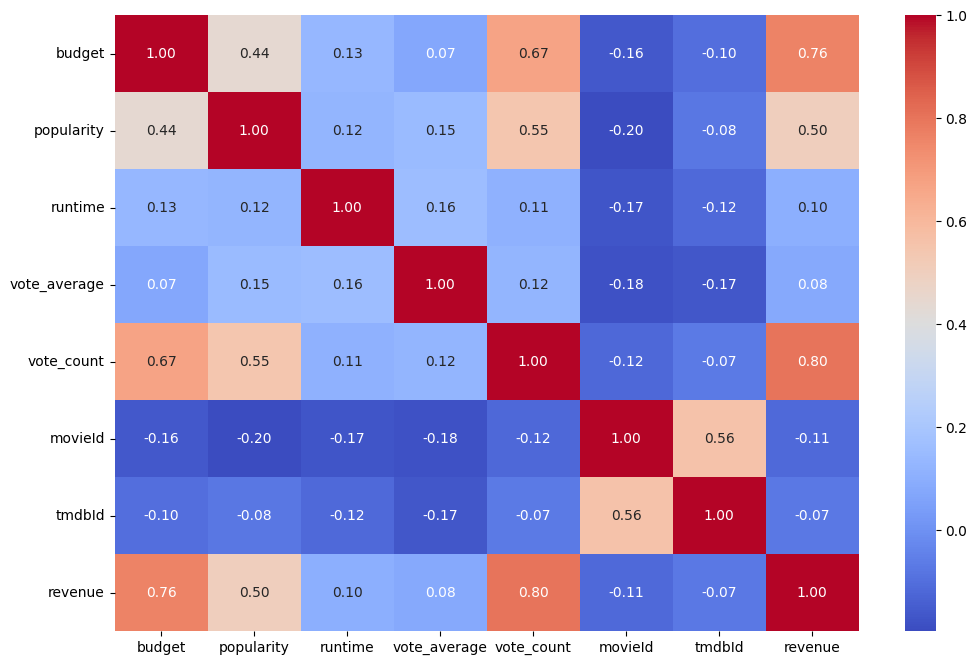

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [42]:
X_train.drop(columns=["movieId", "tmdbId"], inplace=True)
X_test.drop(columns=["movieId", "tmdbId"], inplace=True)

In [43]:
X_train.drop(columns=["overview", "title",'poster_path'], inplace=True)
X_test.drop(columns=["overview", "title",'poster_path'], inplace=True)

In [44]:
X_train.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres',
       'original_language', 'popularity', 'production_companies',
       'production_countries', 'runtime', 'status', 'vote_average',
       'vote_count', 'director', 'Actors', 'release_year', 'release_month'],
      dtype='object')

In [45]:
# Categorical columns


# Numerical columns
num_cols = X_train.select_dtypes(exclude="object").columns

In [46]:
print(X_train[num_cols].skew().sort_values(ascending=False))

runtime          4.740916
budget           1.628873
vote_count       0.848446
popularity       0.793153
release_month   -0.074466
release_year    -1.225223
vote_average    -1.534199
dtype: float64


In [47]:
Q1 = X_train["runtime"].quantile(0.25)
Q3 = X_train["runtime"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train["runtime"] = X_train["runtime"].clip(lower, upper)
X_test["runtime"] = X_test["runtime"].clip(lower, upper)

In [48]:
y_original = np.expm1(y)

print((y_original == 0).sum())
print((y_original != 0).sum())

37903
7420


c:\Users\skyhawk\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [49]:
print(y.max())

2787965087.0


In [50]:
print(y.describe())


count    4.532300e+04
mean     1.125090e+07
std      6.442788e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.787965e+09
Name: revenue, dtype: float64


In [51]:
print((df["revenue"] == 0).sum())

37903


In [52]:
df.head()

,adult,belongs_to_collection,budget,genres,original_language,overview,popularity,poster_path,production_companies,production_countries,revenue,runtime,status,title,vote_average,vote_count,movieId,tmdbId,director,Actors,release_year,release_month
0,False,Toy Story Collection,30000000,"Animation, Comedy, Family",en,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,Pixar Animation Studios,United States of America,373554033.0,81.0,Released,Toy Story,7.7,5415.0,1,862,John Lasseter,"Tom Hanks, Tim Allen, Don Rickles",1995,10
1,False,,65000000,"Adventure, Fantasy, Family",en,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"TriStar Pictures, Teitler Film, Interscope Com...",United States of America,262797249.0,104.0,Released,Jumanji,6.9,2413.0,2,8844,Joe Johnston,"Robin Williams, Jonathan Hyde, Kirsten Dunst",1995,12
2,False,Grumpy Old Men Collection,0,"Romance, Comedy",en,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"Warner Bros., Lancaster Gate",United States of America,0.0,101.0,Released,Grumpier Old Men,6.5,92.0,3,15602,Howard Deutch,"Walter Matthau, Jack Lemmon, Ann-Margret",1995,12
3,False,,16000000,"Comedy, Drama, Romance",en,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,Twentieth Century Fox Film Corporation,United States of America,81452156.0,127.0,Released,Waiting to Exhale,6.1,34.0,4,31357,Forest Whitaker,"Whitney Houston, Angela Bassett, Loretta Devine",1995,12
4,False,Father of the Bride Collection,0,Comedy,en,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"Sandollar Productions, Touchstone Pictures",United States of America,76578911.0,106.0,Released,Father of the Bride Part II,5.7,173.0,5,11862,Charles Shyer,"Steve Martin, Diane Keaton, Martin Short",1995,2


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor
import joblib


cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


for col in cat_features:
    X[col] = X[col].fillna("Unknown")

num_cols = X.select_dtypes(exclude=["object"]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())



# ==========================
# CatBoost Model
# ==========================
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# ==========================
# Prediction
# ==========================
# pred = model.predict(X_test)

# pred_original = np.expm1(pred)
# y_original = np.expm1(y_test)

# print("R2 =", r2_score(y_original, pred_original))
# print("MAE =", mean_absolute_error(y_original, pred_original))

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# لو كنتِ مستخدمة log1p
train_pred = np.expm1(train_pred)
test_pred = np.expm1(test_pred)

y_train_original = np.expm1(y_train)
y_test_original = np.expm1(y_test)

print("Train R2:", r2_score(y_train_original, train_pred))
print("Test R2 :", r2_score(y_test_original, test_pred))



0:	learn: 5.9399763	test: 5.9097374	best: 5.9097374 (0)	total: 154ms	remaining: 2m 34s
100:	learn: 3.5788174	test: 3.6661583	best: 3.6661583 (100)	total: 7.38s	remaining: 1m 5s
200:	learn: 3.4631793	test: 3.5997279	best: 3.5997279 (200)	total: 14.6s	remaining: 58s
300:	learn: 3.4007998	test: 3.5857245	best: 3.5857245 (300)	total: 22.4s	remaining: 52s
400:	learn: 3.3460759	test: 3.5727395	best: 3.5727395 (400)	total: 29.2s	remaining: 43.6s
500:	learn: 3.2975629	test: 3.5697888	best: 3.5690552 (462)	total: 36s	remaining: 35.8s
600:	learn: 3.2536527	test: 3.5687114	best: 3.5686530 (599)	total: 42.7s	remaining: 28.4s
700:	learn: 3.2085819	test: 3.5698992	best: 3.5686530 (599)	total: 49.5s	remaining: 21.1s
800:	learn: 3.1692162	test: 3.5719487	best: 3.5686530 (599)	total: 57s	remaining: 14.2s
900:	learn: 3.1371031	test: 3.5732999	best: 3.5686530 (599)	total: 1m 4s	remaining: 7.08s
999:	learn: 3.1044738	test: 3.5759712	best: 3.5686530 (599)	total: 1m 11s	remaining: 0us

bestTest = 3.56865297

In [54]:
import joblib

joblib.dump(model, "catboost_movie_model.pkl",compress=3)

['catboost_movie_model.pkl']

In [ ]:
print(X_train.shape)
print(X_test.shape)

# print("Train RMSE:", np.sqrt(np.mean((train_pred - y_train_original)**2)))
print("Test RMSE :", np.sqrt(np.mean((test_pred - y_test_original)**2)))

(36258, 16)
(9065, 16)
Train RMSE: 38384934.805012174
Test RMSE : 32149734.12878222
